# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (time-based, price-based, distance-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance  

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

In [2]:
DATA_PATH = "C:/Users/hussa/OneDrive/Desktop/Lab-5/Data/Dataset.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
5,5 Series,2016,14900,Automatic,35309,Diesel,125,60.1,2.0
6,5 Series,2017,16000,Automatic,38538,Diesel,125,60.1,2.0
7,2 Series,2018,16250,Manual,10401,Petrol,145,52.3,1.5
8,4 Series,2017,14250,Manual,42668,Diesel,30,62.8,2.0
9,5 Series,2016,14250,Automatic,36099,Diesel,20,68.9,2.0


The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks (cleanliness confirmation)

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (10781, 9)

Missing values per column:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
missing_count,0,0,0,0,0,0,0,0,0



Duplicate rows: 117


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [5]:
target_col = "model"
df[target_col].value_counts()

model
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4           108
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            27
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64

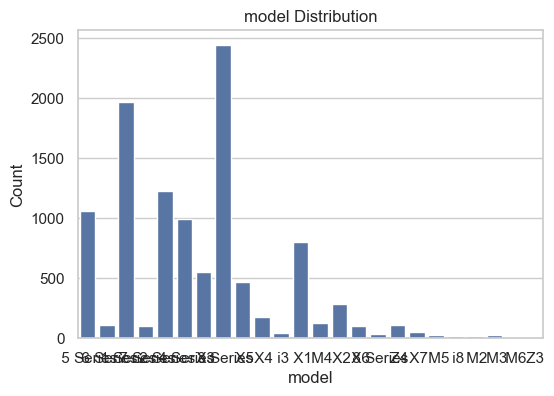

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("model Distribution")
plt.xlabel("model")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [8]:
df.dtypes

model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
tax               int64
mpg             float64
engineSize      float64
dtype: object

We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

For example, if we want to predict the car price when the listing is created, we should not use:

• Price (this is the target variable)
• Any derived feature that uses price (e.g., price_per_mileage or price_category)

## 7. Feature engineering

### 7.1 Time-based features from `year`
We convert car manufacturing year into car age, which may better represent vehicle depreciation.:
- car_age  
- mileage_per_year  



In [9]:
df_fe = df.copy()

# Create car age feature
current_year = 2025
df_fe["car_age"] = current_year - df_fe["year"]

# Mileage per year (driving intensity)
df_fe["mileage_per_year"] = df_fe["mileage"] / (df_fe["car_age"] + 1)

df_fe[["year","car_age","mileage","mileage_per_year"]].head(10)

,year,car_age,mileage,mileage_per_year
0,2014,11,67068,5589.000000
1,2018,7,14827,1853.375000
2,2016,9,62794,6279.400000
3,2017,8,26676,2964.000000
4,2014,11,39554,3296.166667
5,2016,9,35309,3530.900000
6,2017,8,38538,4282.000000
7,2018,7,10401,1300.125000
8,2017,8,42668,4740.888889
9,2016,9,36099,3609.900000


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.


### 7.2 Engine and efficiency based features
We create a feature that captures fuel efficiency relative to engine size:
efficiency_ratio = mpg / engineSize

This helps the model understand how efficiently a vehicle performs relative to its engine capacity.

In [10]:
df_fe["efficiency_ratio"] = df_fe["mpg"] / df_fe["engineSize"]

df_fe[["mpg","engineSize","efficiency_ratio"]].head(10)

,mpg,engineSize,efficiency_ratio
0,57.6,2.0,28.800000
1,42.8,2.0,21.400000
2,51.4,3.0,17.133333
3,72.4,1.5,48.266667
4,50.4,3.0,16.800000
5,60.1,2.0,30.050000
6,60.1,2.0,30.050000
7,52.3,1.5,34.866667
8,62.8,2.0,31.400000
9,68.9,2.0,34.450000


### 7.3 7.3 Optional: Transmission Encoding
Since transmission is a categorical feature (Manual, Automatic, Semi-Auto), we convert it into numerical form using encoding so that machine learning models can process it.


In [11]:
df_fe = pd.get_dummies(df_fe, columns=["transmission"], drop_first=True)

df_fe.head(10)

,model,year,price,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,efficiency_ratio,transmission_Manual,transmission_Semi-Auto
0,5 Series,2014,11200,67068,Diesel,125,57.6,2.0,11,5589.000000,28.800000,False,False
1,6 Series,2018,27000,14827,Petrol,145,42.8,2.0,7,1853.375000,21.400000,False,False
2,5 Series,2016,16000,62794,Diesel,160,51.4,3.0,9,6279.400000,17.133333,False,False
3,1 Series,2017,12750,26676,Diesel,145,72.4,1.5,8,2964.000000,48.266667,False,False
4,7 Series,2014,14500,39554,Diesel,160,50.4,3.0,11,3296.166667,16.800000,False,False
5,5 Series,2016,14900,35309,Diesel,125,60.1,2.0,9,3530.900000,30.050000,False,False
6,5 Series,2017,16000,38538,Diesel,125,60.1,2.0,8,4282.000000,30.050000,False,False
7,2 Series,2018,16250,10401,Petrol,145,52.3,1.5,7,1300.125000,34.866667,True,False
8,4 Series,2017,14250,42668,Diesel,30,62.8,2.0,8,4740.888889,31.400000,True,False
9,5 Series,2016,14250,36099,Diesel,20,68.9,2.0,9,3609.900000,34.450000,False,False


### 7.4 Reducing high-cardinality categories (example: model)
model may have many unique values. If we one-hot encode all models, the feature space becomes very large.

A common feature engineering approach is to keep the most frequent categories and map the rest to "Other".


In [12]:
if "model" in df_fe.columns:

    top_k = 20
    top_models = df_fe["model"].value_counts().head(top_k).index

    df_fe["model_reduced"] = np.where(
        df_fe["model"].isin(top_models),
        df_fe["model"],
        "Other"
    )

    print("Unique model:", df_fe["model"].nunique())
    print("Unique model_reduced:", df_fe["model_reduced"].nunique())

    df_fe[["model","model_reduced"]].head(10)

else:
    print("model column not found.")

Unique model: 24
Unique model_reduced: 21


We reduced the cardinality of the model feature by keeping the 20 most frequent car models and mapping the rest to Other.
This helps reduce the number of features created during encoding and improves model stability.

## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).
This can help some models capture non-linear relationships and also improves interpretability.

Here we discretize mileage into usage tiers.

In [13]:
df_fe["mileage_tier"] = pd.cut(
    df_fe["mileage"],
    bins=[0, 20000, 60000, 120000, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

df_fe[["mileage", "mileage_tier"]].head(10)

,mileage,mileage_tier
0,67068,high
1,14827,low
2,62794,high
3,26676,medium
4,39554,medium
5,35309,medium
6,38538,medium
7,10401,low
8,42668,medium
9,36099,medium


We discretized the mileage feature into four tiers (low, medium, high, very high).
This allows the model to better capture differences between lightly used and heavily used vehicles.

## 9. Prepare features for modeling

Target = price

We should drop the original model if we use model_reduced

Keep engineered features

In [14]:
# Target column
target_col = "price"

# Columns we want to drop
drop_cols = [
    "model"  # replaced with model_reduced
]

# Keep only columns that exist (safe practice)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

# Split predictors and target
X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (10781, 13)
y shape: (10781,)


,year,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,efficiency_ratio,transmission_Manual,transmission_Semi-Auto,model_reduced,mileage_tier
0,2014,67068,Diesel,125,57.6,2.0,11,5589.000000,28.800000,False,False,5 Series,high
1,2018,14827,Petrol,145,42.8,2.0,7,1853.375000,21.400000,False,False,6 Series,low
2,2016,62794,Diesel,160,51.4,3.0,9,6279.400000,17.133333,False,False,5 Series,high
3,2017,26676,Diesel,145,72.4,1.5,8,2964.000000,48.266667,False,False,1 Series,medium
4,2014,39554,Diesel,160,50.4,3.0,11,3296.166667,16.800000,False,False,7 Series,medium


We now select our predictors.

We drop:

model (replaced with model_reduced)

We keep:

early available numeric variables

categorical variables

engineered features created in the previous steps

## 10. Split into train and test sets

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8624, 13)
Test size: (2157, 13)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns: ['fuelType', 'model_reduced', 'mileage_tier']
Numeric columns: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age', 'mileage_per_year', 'efficiency_ratio', 'transmission_Manual', 'transmission_Semi-Auto']


C:\Users\hussa\AppData\Local\Temp\ipykernel_20948\1803529777.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 12. Train the model and evaluate

In [26]:
import numpy as np

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values with median
X = X.fillna(X.median(numeric_only=True))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

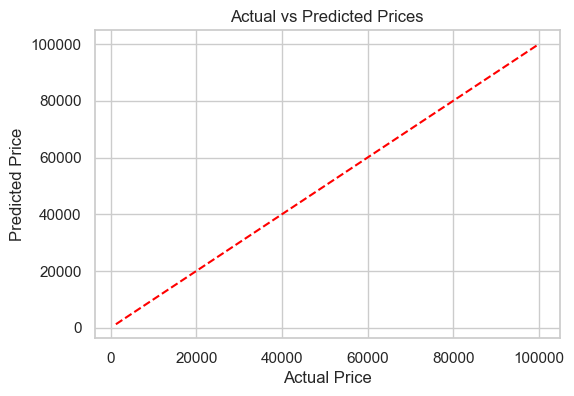

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_train)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [33]:
import pandas as pd
import numpy as np

# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]

if len(categorical_cols) > 0:
    cat_feature_names = ohe.get_feature_names_out(categorical_cols)
else:
    cat_feature_names = np.array([])

all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

# Get feature importances from Random Forest
importances = model.named_steps["rf"].feature_importances_

fi = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(15)

,feature,importance
37,efficiency_ratio,0.257697
30,year,0.234427
35,car_age,0.217774
34,engineSize,0.072099
31,mileage,0.046732
33,mpg,0.023720
36,mileage_per_year,0.017347
25,model_reduced_Other,0.017061
20,model_reduced_ X5,0.015550
38,transmission_Manual,0.014931


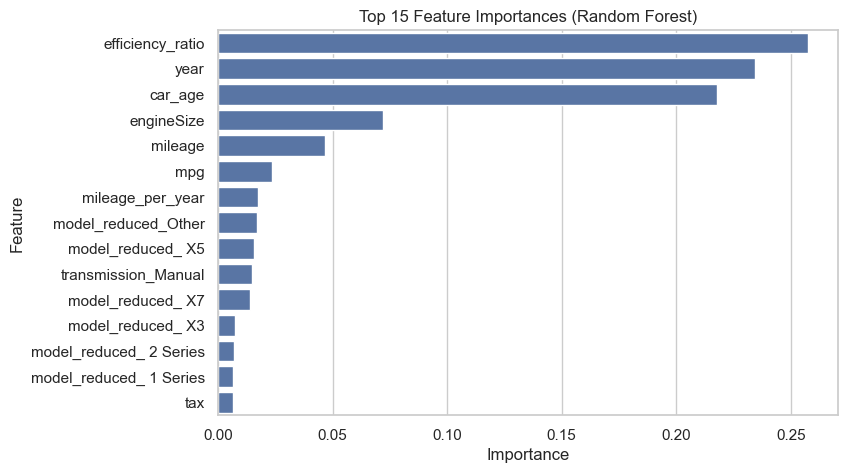

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

top_n = 15

sns.barplot(
    data=fi.head(top_n),
    x="importance",
    y="feature"
)

plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [35]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Feature selector based on Random Forest importances
selector = SelectFromModel(
    estimator=RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    threshold="median"
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

model_fs.fit(X_train, y_train)

y_pred_fs = model_fs.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_fs)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_fs))
r2 = r2_score(y_test, y_pred_fs)

print("MAE (with feature selection):", round(mae, 2))
print("RMSE (with feature selection):", round(rmse, 2))
print("R² (with feature selection):", round(r2, 4))

MAE (with feature selection): 1710.65
RMSE (with feature selection): 2926.61
R² (with feature selection): 0.9338


If performance stays similar, feature selection may help simplify the model with minimal accuracy loss.  
If performance drops, it may indicate that important information was removed.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.

### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.

### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.


## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.
